# Video Game Market Analysis

You are working for the online store "StreamChik," which sells computer games worldwide. Historical game sales data, user and expert ratings, genres, and platforms (such as Xbox or PlayStation) are publicly available. Your goal is to identify patterns that determine the success of a game. This will help to focus on potentially popular products and plan advertising campaigns accordingly.

You have data up to 2016. Assume it is currently December 2016, and you are planning a campaign for 2017. The purpose is to practice the data handling principle. Whether you forecast 2017 sales based on 2016 data or 2027 sales based on 2026 data, the logic remains the same.

The dataset includes the abbreviation ESRB (Entertainment Software Rating Board), an association responsible for assigning age ratings to computer games. ESRB evaluates game content and assigns appropriate age categories such as "Adults," "Early Childhood," or "Teen."

---


**Data Description**

- **Name** — Game title  
- **Platform** — Platform  
- **Year_of_Release** — Release year  
- **Genre** — Game genre  
- **NA_sales** — Sales in North America (millions of copies sold)  
- **EU_sales** — Sales in Europe (millions of copies sold)  
- **JP_sales** — Sales in Japan (millions of copies sold)  
- **Other_sales** — Sales in other countries (millions of copies sold)  
- **Critic_Score** — Critics' score (maximum of 100)  
- **User_Score** — User score (maximum of 10)  
- **Rating** — ESRB (Entertainment Software Rating Board) age category rating

> *Note: Data for 2016 may be incomplete.*

---

**Research Goal**

Identify patterns that determine a game's success. The research outcomes will help:

- Determine factors influencing product popularity.
- Create a profile of potentially successful products.
- Plan advertising campaigns to promote games.

---

**Research Steps**

1. **Data Loading and Preprocessing:**  
   - Importing and initial analysis of the dataset.
   - Data cleaning and handling missing values.
   - Converting data to necessary types.

2. **Exploratory Data Analysis (EDA):**  
   - Analyzing sales distribution in North America, Europe, Japan, and other regions.
   - Exploring relationships between critic and user ratings.
   - Identifying patterns by genre, platform, and release year.

3. **Regional User Profiles:**  
   - Creating a profile of typical gamers in North America, Europe, and Japan.
   - Comparing popular genres and sales levels by region.

4. **Hypothesis Testing:**  
   - **Hypothesis 1:** Are the average user ratings the same for Xbox One and PC platforms?
   - **Hypothesis 2:** Do the genres Action and Sports have different average user ratings?  
   Statistical tests will be applied to test these hypotheses.

5. **Conclusion:**  
   - Developing recommendations on development and marketing strategies based on identified patterns.



### Open the data file and explore general information


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st
import numpy as np

In [2]:
# Reading the CSV file with data
df = pd.read_csv('https://code.s3.yandex.net/datasets/games.csv')

In [3]:
# Display the rows
df.head(20)


,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
5,Tetris,GB,1989.0,Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,NaN
6,New Super Mario Bros.,DS,2006.0,Platform,11.28,9.14,6.50,2.88,89.0,8.5,E
7,Wii Play,Wii,2006.0,Misc,13.96,9.18,2.93,2.84,58.0,6.6,E
8,New Super Mario Bros. Wii,Wii,2009.0,Platform,14.44,6.94,4.70,2.24,87.0,8.4,E
9,Duck Hunt,NES,1984.0,Shooter,26.93,0.63,0.28,0.47,NaN,NaN,NaN


In [4]:
# View general information about the dataset
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [5]:
# Display the number of duplicated rows
df.duplicated().sum()


0

In [6]:
# Check for non obvious duplicates
df.duplicated(subset=['Name', 'Platform', 'Critic_Score', 'Rating']).sum()


5

In [7]:
# Remove non-obvious duplicates
df = df.drop_duplicates(subset=['Name', 'Platform', 'Critic_Score', 'Rating'])

# Double-check for remaining duplicates
df.duplicated(subset=['Name', 'Platform', 'Critic_Score', 'Rating']).sum()


0

**Conclusion:**

- **Column names** need to be converted to lowercase.  
- **Data types:**  
  - *year_of_release* — should be converted to **int**.  
  - *critic_score* — should be converted to **int** (rated from 0 to 100).  
  - *user_score* — should be converted to **float**.  
- **Missing values:**  
  Found in *Name, Year_of_Release, Genre, Critic_Score, User_Score, Rating*.  
  Handling missing values will be a crucial part of the data preprocessing.  
- **Duplicates:**  
  A check for duplicates was performed: no full duplicate rows were found.  
  5 partial (non-obvious) duplicates were found and removed.
ли удалены.


### Data Preparation


#### Renaming Column Headers


In [8]:
# Convert column names to lowercase
df.columns = df.columns.str.lower()

# Check the result
df.columns


Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')

#### Missing Values


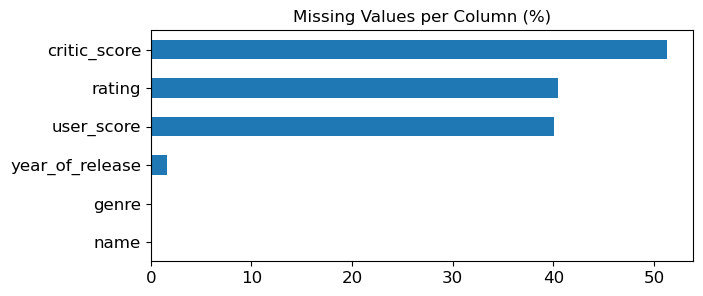

In [9]:
try:
    (
        (df.isna().mean() * 100)
        .to_frame()
        .rename(columns={0: 'space'})
        .query('space > 0')
        .sort_values(by='space', ascending=True)
        .plot(kind='barh', figsize=(7, 3), rot=0, legend=False, fontsize=12)
        .set_title('Missing Values per Column (%)')    
    )
except:
    print('No missing values left :) or an error occurred in the first part of the function')


In [10]:
# Display number of missing values for each column
df.isna().sum()


name                  1
platform              0
year_of_release     268
genre                 1
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8577
user_score         6700
rating             6765
dtype: int64

The **name**, **year_of_release**, and **genre** columns contain only a small number of missing values — these rows can be safely removed.


In [11]:
# Drop rows with missing values in key columns
df = df.dropna(subset=['name', 'year_of_release', 'genre']).reset_index(drop=True)


A **large number of missing values** was found in the **rating**, **critic_score**, and **user_score** columns.  
The reason could be that the games were not rated or the data was lost.

- We will replace missing values in the **rating** column with **'undefined'**.
- The rest will be left unchanged, as replacing them could significantly distort the results.

Let's take a closer look at these columns.


In [12]:
# View unique values for 'user_score'
df['user_score'].sort_values().unique()


array(['0', '0.2', '0.3', '0.5', '0.6', '0.7', '0.9', '1', '1.1', '1.2',
       '1.3', '1.4', '1.5', '1.6', '1.7', '1.8', '1.9', '2', '2.1', '2.2',
       '2.3', '2.4', '2.5', '2.6', '2.7', '2.8', '2.9', '3', '3.1', '3.2',
       '3.3', '3.4', '3.5', '3.6', '3.7', '3.8', '3.9', '4', '4.1', '4.2',
       '4.3', '4.4', '4.5', '4.6', '4.7', '4.8', '4.9', '5', '5.1', '5.2',
       '5.3', '5.4', '5.5', '5.6', '5.7', '5.8', '5.9', '6', '6.1', '6.2',
       '6.3', '6.4', '6.5', '6.6', '6.7', '6.8', '6.9', '7', '7.1', '7.2',
       '7.3', '7.4', '7.5', '7.6', '7.7', '7.8', '7.9', '8', '8.1', '8.2',
       '8.3', '8.4', '8.5', '8.6', '8.7', '8.8', '8.9', '9', '9.1', '9.2',
       '9.3', '9.4', '9.5', '9.6', '9.7', 'tbd', nan], dtype=object)

- **'0'** — a valid score.  
- **nan** — missing value.  
- **'tbd'** — TBD (*To Be Determined* or *To Be Decided*).  
  This acronym indicates that some information is not yet available or a decision hasn't been made. It's used to mark missing values that need to be filled in later.

We'll replace all **'tbd'** values with **nan**.


In [13]:
# Replace 'tbd' with NaN
df['user_score'] = df['user_score'].replace('tbd', np.nan)

# Check how many 'tbd' values remain
(df['user_score'] == 'tbd').sum()


0

In [14]:
# Fill missing values in the 'rating' column with 'undefined'
df['rating'] = df['rating'].fillna('undefined')


In [15]:
# Check the number of missing values after replacements
df.isna().sum()


name                  0
platform              0
year_of_release       0
genre                 0
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8461
user_score         8981
rating                0
dtype: int64

#### Convert Data to Appropriate Types


In [16]:
# View unique values for 'critic_score'
df['critic_score'].sort_values().unique()


array([13., 17., 19., 20., 21., 23., 24., 25., 26., 27., 28., 29., 30.,
       31., 32., 33., 34., 35., 36., 37., 38., 39., 40., 41., 42., 43.,
       44., 45., 46., 47., 48., 49., 50., 51., 52., 53., 54., 55., 56.,
       57., 58., 59., 60., 61., 62., 63., 64., 65., 66., 67., 68., 69.,
       70., 71., 72., 73., 74., 75., 76., 77., 78., 79., 80., 81., 82.,
       83., 84., 85., 86., 87., 88., 89., 90., 91., 92., 93., 94., 95.,
       96., 97., 98., nan])

In [17]:
# Convert year_of_release to int and user_score to float
df['year_of_release'] = df['year_of_release'].astype(int)
df['user_score'] = df['user_score'].astype(float)


**year_of_release** — converted to **int**, since a year cannot be a fractional number.

**user_score** — converted from object to **float**.

**critic_score** — will be converted to **int**, since it's a numerical score from 0 to 100.


#### Calculate total sales across all regions and save them to a new column


In [18]:
# Create a new column for total global sales
df['all_sales'] = (
    df['na_sales'] +
    df['eu_sales'] +
    df['jp_sales'] +
    df['other_sales']
)


#### Data Preparation Summary

- Column names were converted to lowercase.  
- Data types were adjusted:
  - `year_of_release` → int  
  - `user_score` → float  
  - `critic_score` will be converted to int (if possible).
- Missing values:
  - Rows with missing values in `name`, `year_of_release`, `genre` were dropped.
  - `tbd` in `user_score` was replaced with NaN.
  - Missing values in `rating` were replaced with `'undefined'`.
- A new column `total_sales` was created to store global sales for each game.


## Exploratory Data Analysis (EDA)


#### Let's look at how many games were released in different years.



In [19]:
# Group data by release year and count number of games
games_per_year = df.groupby('year_of_release')['name'].count().reset_index()
games_per_year.columns = ['year', 'number_of_games']


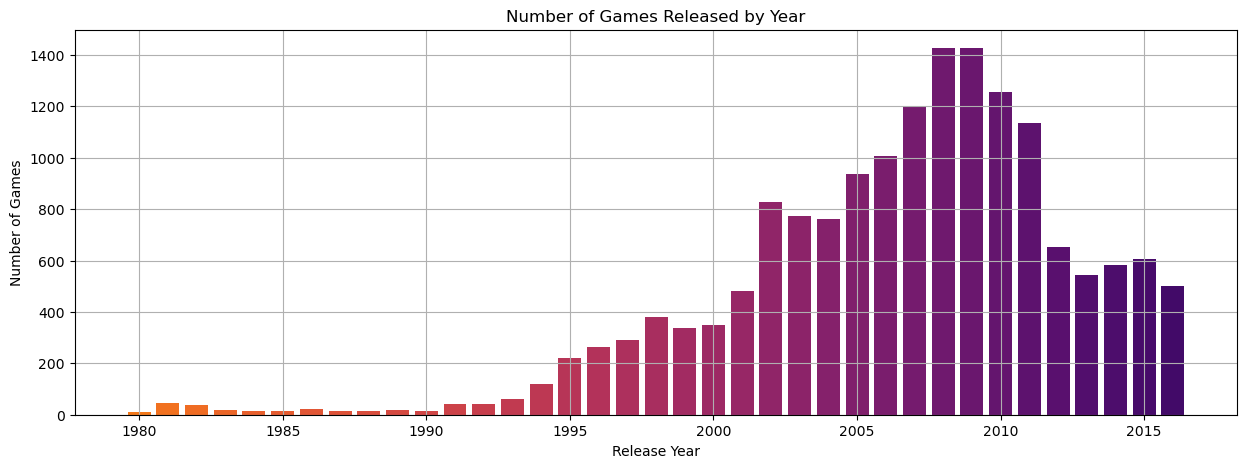

In [20]:
# Plot the data
plt.figure(figsize=(15, 5))

# Generate a color gradient from the 'inferno' colormap
colors = plt.cm.inferno(np.linspace(0.7, 0.2, len(games_per_year['year'])))

plt.bar(games_per_year['year'], games_per_year['number_of_games'], color=colors)
plt.title('Number of Games Released by Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Games')
plt.grid(True)
plt.show()


**Conclusion:**  

The chart shows that the number of games released started growing around the mid-1990s and peaked between **2005** and **2010**. After **2010**, the number of releases began to decline.

**Are all historical periods important?**

Knowing how many games were released is useful for understanding general trends and identifying the life cycle of successful platforms.

Since the goal of this study is to determine the factors behind a game’s success, focus on potentially popular products, and plan marketing campaigns — it is sufficient to analyze only the most recent years, as trends and gaming preferences evolve over time.


#### Let's examine how platform sales have changed.

We select the platforms with the highest total sales and plot their distribution over the years. What is the typical lifespan during which new platforms emerge and old ones disappear?


In [21]:
platform_sales = df.groupby('platform')['all_sales'].sum().sort_values(ascending=False)
platform_sales.head().to_frame()

,all_sales
platform,
PS2,1233.56
X360,959.99
PS3,931.33
Wii,891.18
DS,802.78


Text(0, 0.5, 'Number of Games (millions)')

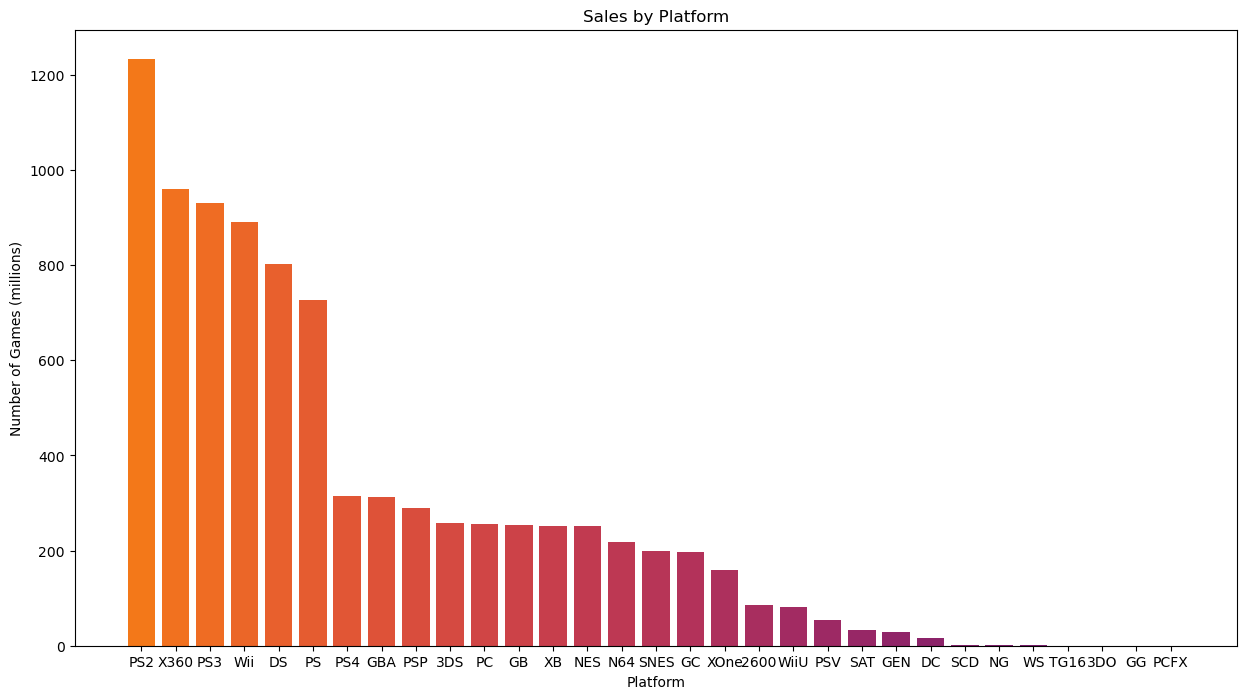

In [22]:
# Plot the sales distribution by platform
plt.figure(figsize=(15, 8))
plt.bar(platform_sales.index, platform_sales.values, color=colors)
plt.title('Sales by Platform')
plt.xlabel('Platform')
plt.ylabel('Number of Games (millions)')


In [23]:
top_platform_sales = platform_sales.head(5)

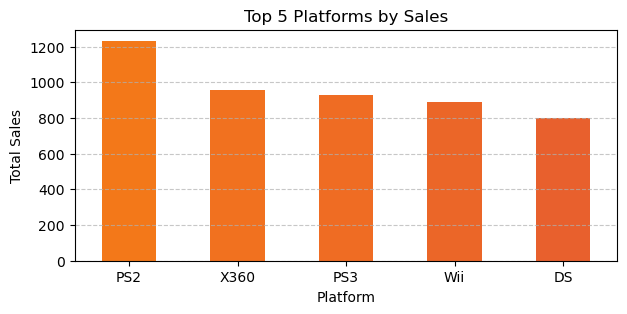

In [24]:
# Creating a bar chart
plt.figure(figsize=(7, 3))
top_platform_sales.plot(kind='bar', color=colors)
plt.title('Top 5 Platforms by Sales')
plt.xlabel('Platform')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)  # Rotate platform labels on the X-axis for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


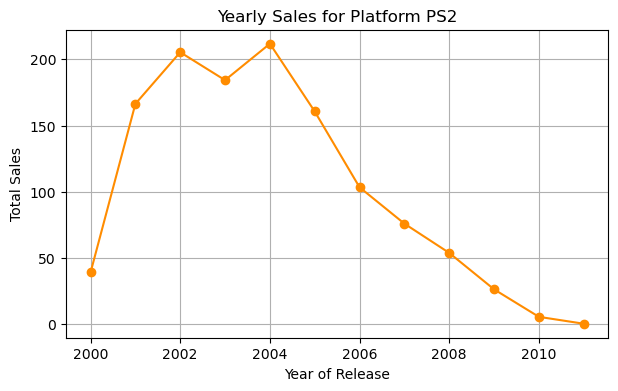

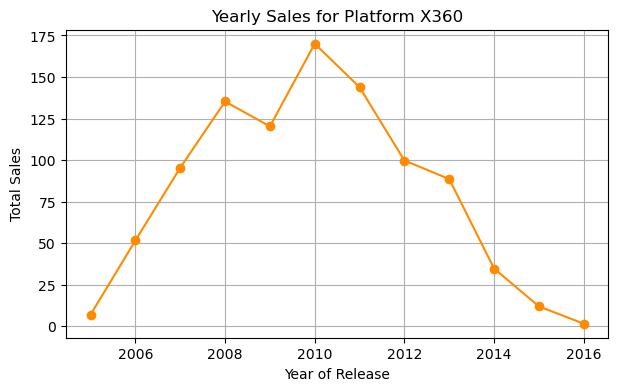

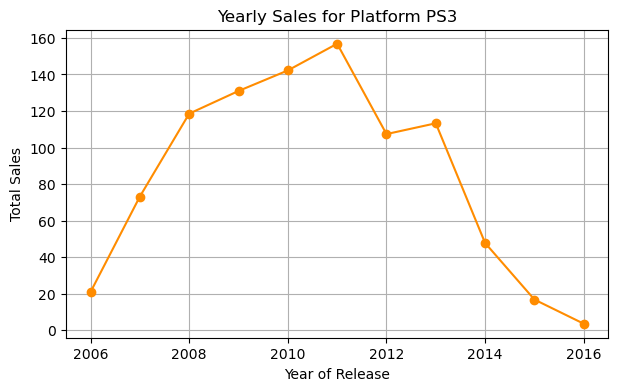

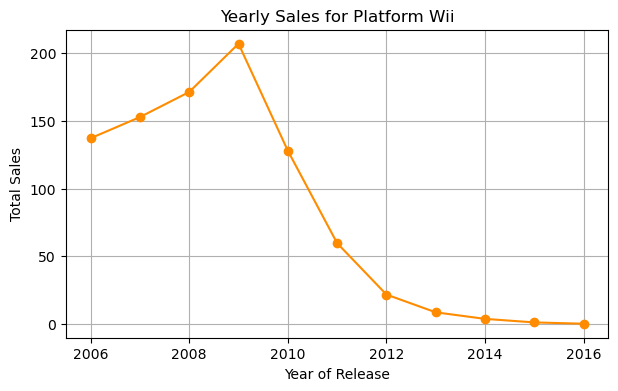

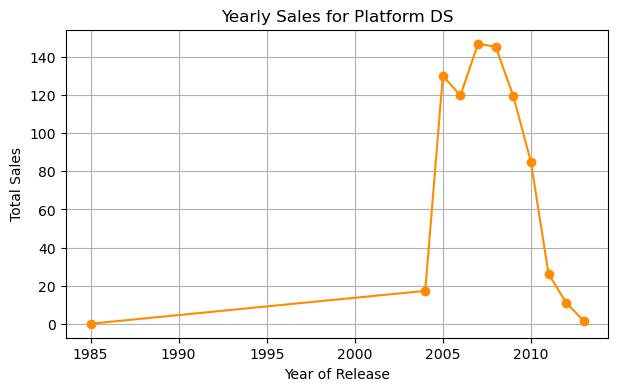

In [25]:
# Creating line charts for each platform
for platform in top_platform_sales.index:
    subset = df[df['platform'] == platform]
    yearly_sales = subset.groupby('year_of_release')['all_sales'].sum()
    plt.figure(figsize=(7, 4))
    plt.plot(yearly_sales.index, yearly_sales, marker='o', linestyle='-', color='darkorange')
    plt.title(f'Yearly Sales for Platform {platform}')
    plt.xlabel('Year of Release')
    plt.ylabel('Total Sales')
    plt.grid(True)
    plt.show()


What is the typical timeframe during which new platforms emerge and old ones disappear?

**Conclusion:**

- 3 out of the 5 most successful platforms were launched around **2006**, with peak sales around **2010**. By 2016, sales had declined to their initial levels.
- The other 2 platforms, which launched earlier, peaked in **2007**. This suggests that the earlier a platform's growth begins, the earlier it reaches peak sales, followed by a decline.
- **PS2** – launched in **2000**, experienced immediate sales growth, peaked between **2002–2004**, and then gradually declined from **2004 to 2011**.
- **DS** – launched in **1985**, saw a sharp increase starting in **2004**, peaked in **2007–2008**, and declined from **2008 to 2011**.
- The **life cycle** of such platforms is approximately **10 years**: 3–5 years of growth, a peak, followed by 5–7 years of decline. An exception is the DS, which showed modest growth for almost 20 years before a sudden surge, after which its lifecycle resembled that of other platforms.
- Peak sales for these platforms occurred between **2005–2010** (the highest overall period for video game sales).
- Many major gaming platforms like **PlayStation**, **Xbox**, and **Nintendo** have a typical lifecycle of around **10 years**, with peak sales occurring within the first 3–5 years after launch.апуска.


#### Let's take data for the relevant recent period.  
To build a forecast for 2017, it's better to use data starting from 2012, since there was a peak in video game sales before 2011, and now the sales are lower.

In [26]:
# filter
df_actual = df[df['year_of_release'] > 2011]

#### Which platforms are leading in sales, growing or declining? Select a few potentially profitable platforms.

In [27]:
platform_sales_actual = df_actual.groupby('platform')['all_sales'].sum().sort_values(ascending=False)
platform_sales_actual.head().to_frame()

,all_sales
platform,
PS4,314.14
PS3,288.78
X360,236.54
3DS,194.61
XOne,159.32


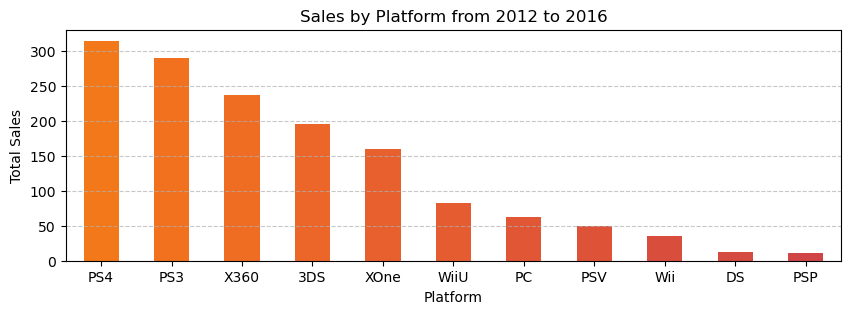

In [28]:
# Creating a bar chart  
plt.figure(figsize=(10, 3))  
platform_sales_actual.plot(kind='bar', color=colors)  
plt.title('Sales by Platform from 2012 to 2016')  
plt.xlabel('Platform')  
plt.ylabel('Total Sales')  
plt.xticks(rotation=0)  # Rotate platform labels on the X-axis for better readability  
plt.grid(axis='y', linestyle='--', alpha=0.7)  
plt.show()

Sales leaders (in descending order) – PS4, PS3, X360, 3DS, XOne.

In [29]:
pivot_df_actual = df_actual.pivot_table(
    index='year_of_release', columns='platform', 
    values='all_sales', aggfunc='sum'
)
pivot_df_actual

platform,3DS,DS,PC,PS3,PS4,PSP,PSV,Wii,WiiU,X360,XOne
year_of_release,,,,,,,,,,,
2012,51.36,11.01,23.14,107.35,NaN,7.69,16.19,21.71,17.56,99.74,NaN
2013,56.57,1.54,12.38,113.25,25.99,3.14,10.59,8.59,21.65,88.58,18.96
2014,43.76,NaN,13.28,47.76,100.00,0.24,11.90,3.75,22.03,34.74,54.07
2015,27.78,NaN,8.52,16.82,118.90,0.12,6.25,1.14,16.35,11.96,60.14
2016,15.14,NaN,5.25,3.60,69.25,NaN,4.25,0.18,4.60,1.52,26.15


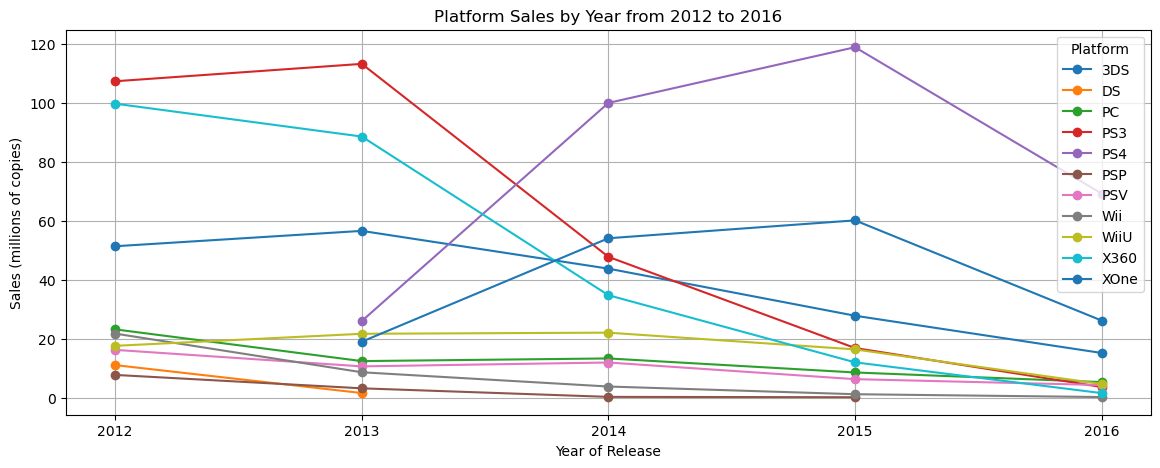

In [30]:
# Visualizing sales across all platforms  
pivot_df_actual.plot(figsize=(14, 5), marker='o', title='Platform Sales by Year from 2012 to 2016')  
plt.xlabel('Year of Release')  
plt.ylabel('Sales (millions of copies)')  
# Set X-axis labels  
plt.xticks(ticks=[2012, 2013, 2014, 2015, 2016])  
plt.grid(True)  
plt.legend(title='Platform')  
plt.show()

**Conclusion:**

- **PS4**: This platform shows the highest sales, with a peak in **2015**. The data for 2016 shows a decline, but the actual situation might differ (the drop may be less sharp, stagnation, or even growth), since the 2016 sales data might be incomplete. In any case, this is potentially the most profitable platform.

- **XOne (Xbox One)**: Also demonstrates good sales, although it lags behind **PS4**. Its sales peak also occurred in **2015**.

- **3DS**: Clearly in decline, with its peak in **2013**. However, considering the decline spans over 5 years, this platform may still generate some sales in 2017.

- The other platforms show low sales and are nearing the end of their life cycle.

Overall, the gradual decline in sales may be associated with decreasing interest in portable gaming systems in favor of smartphones and other mobile devices.стройств.


#### Let's plot a boxplot of global game sales broken down by platform

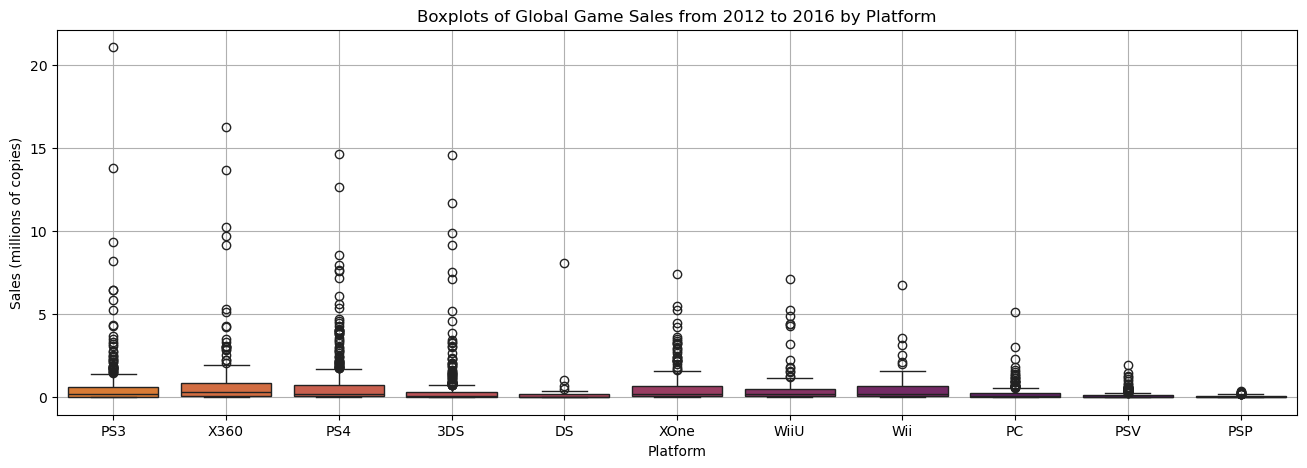

In [31]:
# Get a list of unique platforms from df_actual (to correctly map colors)
unique_platforms = df_actual['platform'].unique()

# Convert 'colors' into a palette for platforms
# The number of colors must match the number of platforms
palette_dict = dict(zip(unique_platforms, plt.cm.inferno(np.linspace(0.7, 0.2, len(unique_platforms)))))

# Build the boxplot with the desired color palette
plt.figure(figsize=(16, 5))
ax = sns.boxplot(x='platform', y='all_sales', hue='platform', data=df_actual, palette=palette_dict)
plt.title('Boxplots of Global Game Sales from 2012 to 2016 by Platform')
plt.xlabel('Platform')
plt.ylabel('Sales (millions of copies)')
plt.xticks(rotation=0)
plt.grid(True)
plt.show()


On the platforms PS3, X360, PS4, and 3DS, there are significant outliers indicating the presence of highly successful games whose sales are significantly above the average level.

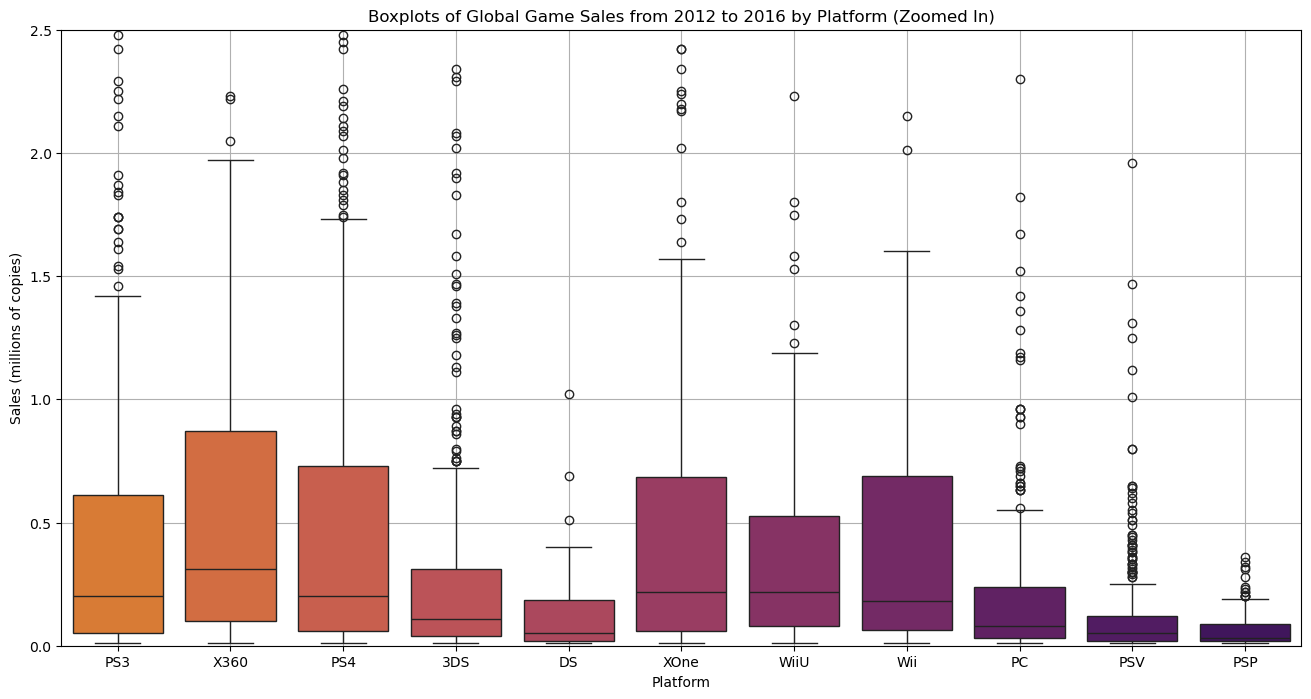

In [32]:
plt.figure(figsize=(16, 8))  
sns.boxplot(x='platform', y='all_sales', hue='platform', 
            data=df_actual, palette=palette_dict)  
plt.title('Boxplots of Global Game Sales from 2012 to 2016 by Platform (Zoomed In)')  
plt.xlabel('Platform')  
plt.ylabel('Sales (millions of copies)')  
plt.xticks(rotation=0)  # Rotate X-axis labels for better readability  
plt.grid(True)  
plt.ylim(0, 2.5)  # Limit outliers  
plt.show()

**Conclusion:**

- The median sales on most platforms are relatively low, indicating that typical game sales on these platforms are modest.
- The interquartile range (distance between the first and third quartiles) is not very wide for most platforms, suggesting more uniform game sales across these platforms.
- **PS4, PS3, X360, 3DS, and XOne** are sales leaders, but their medians, interquartile ranges, and upper whiskers are not significantly different from those of many other platforms.  
  These platforms stand out primarily due to outliers — hit games whose sales are significantly higher than the typical level.

#### How do user and critic reviews affect sales within a single popular platform?  
Let's plot a scatter diagram and calculate the correlation between reviews and sales.

In [33]:
# filter the data for the PS3 platform  
df_PS3 = df_actual.query('platform == "PS3"')

In [34]:
print('Correlation between user ratings and sales:',
      df_PS3['user_score'].corr(df_PS3['all_sales']))

Correlation between user ratings and sales: -0.0062057676860515125


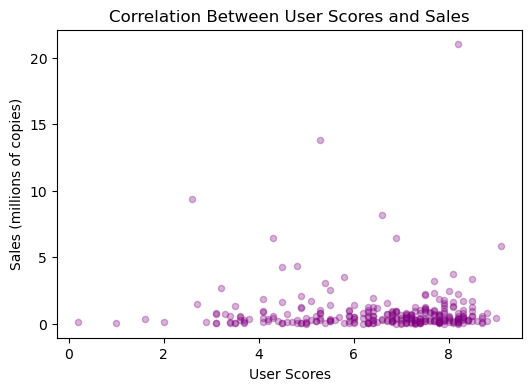

In [35]:
df_PS3.plot(x='user_score', y='all_sales', kind='scatter', color='purple', 
            alpha=0.3, figsize=(6, 4))  
plt.title('Correlation Between User Scores and Sales')  
plt.xlabel('User Scores')  
plt.ylabel('Sales (millions of copies)');

A very low correlation value (-0.005) indicates that user scores have little to no impact on game sales on this platform.

High sales can be observed in games with both high and low user ratings.

In [36]:
print('Correlation between critic scores and sales:',
      df_PS3['critic_score'].corr(df_PS3['all_sales']))

Correlation between critic scores and sales: 0.3341517575509857


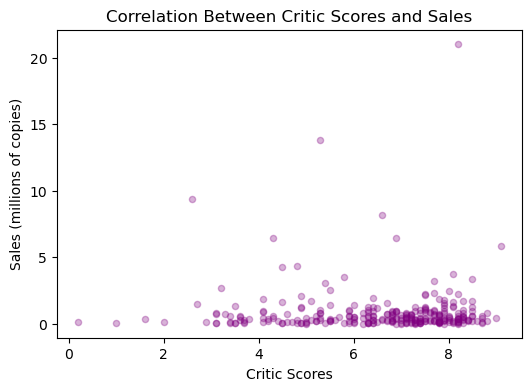

In [37]:
df_PS3.plot(x='user_score', y='all_sales', kind='scatter', color='purple', 
            alpha=0.3, figsize=(6, 4))
plt.title('Correlation Between Critic Scores and Sales')
plt.xlabel('Critic Scores')
plt.ylabel('Sales (millions of copies)');

**Conclusion:**

- The correlation value of **0.331** suggests that higher critic scores may be associated with higher sales. However, this relationship is weak, and many games still sell well even with average critic scores.
- The scatter plot shows that most games have critic scores in the **50 to 80** range and relatively low sales (under **5 million** copies). However, some games with scores above **80** have significantly higher sales (over **10 million** copies), supporting a positive correlation.
- **User scores** do not influence game sales on this platform.

#### Let's compare these findings with game sales on other platforms

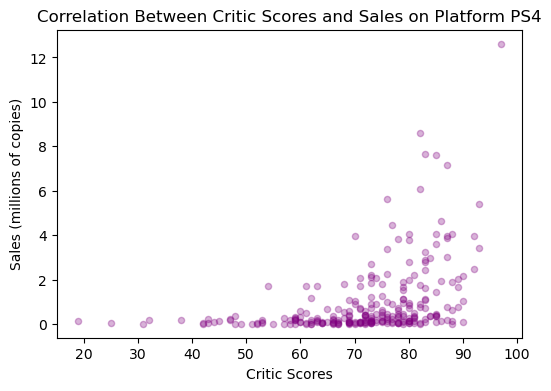

Correlation between critic scores and sales on platform PS4: 0.40656790206178123


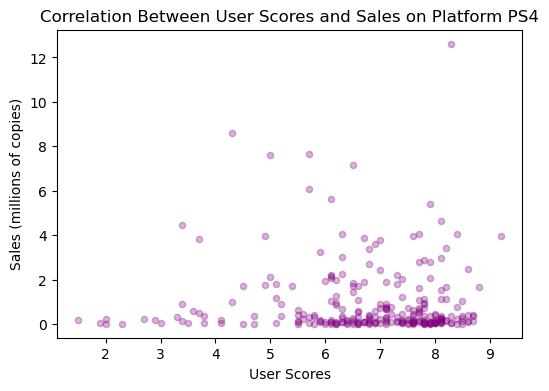

Correlation between user scores and sales on platform PS4: -0.03195711020455644


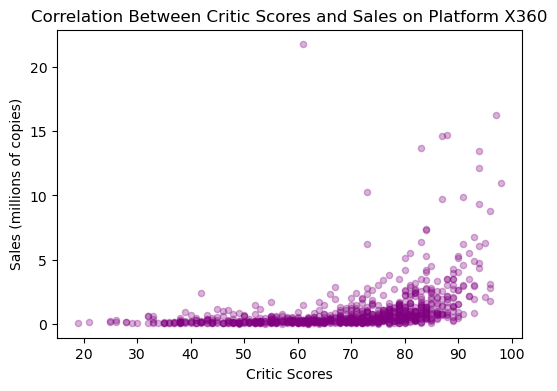

Correlation between critic scores and sales on platform X360: 0.3929021738082897


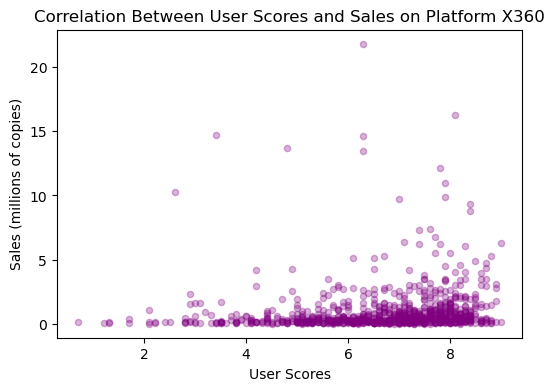

Correlation between user scores and sales on platform X360: 0.11405439431804779


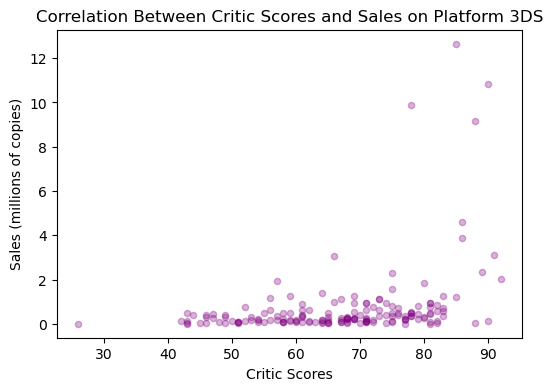

Correlation between critic scores and sales on platform 3DS: 0.34873973059848334


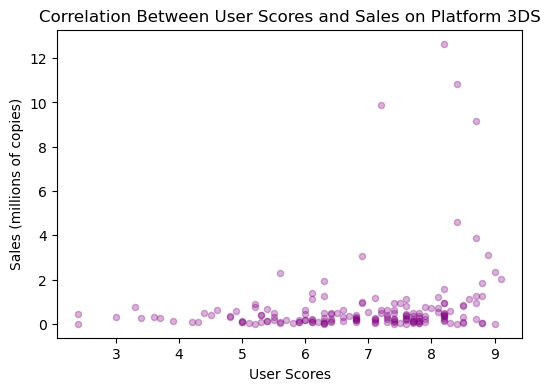

Correlation between user scores and sales on platform 3DS: 0.22207843643390884


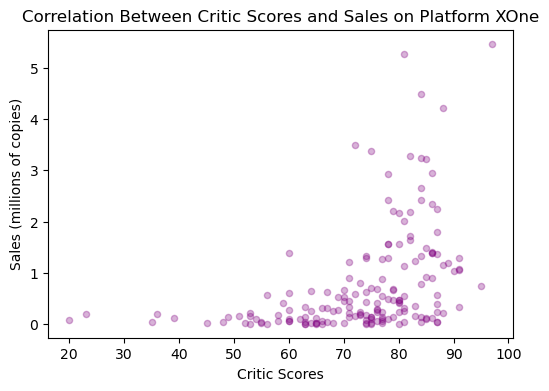

Correlation between critic scores and sales on platform XOne: 0.41699832800840153


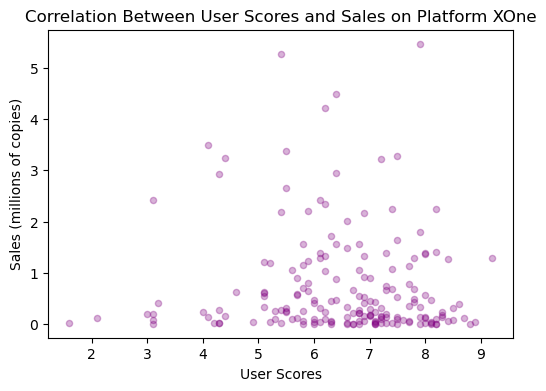

Correlation between user scores and sales on platform XOne: -0.06892505328279418


In [38]:
for n in ['PS4', 'X360', '3DS', 'XOne']:
    df_select = df.query('platform == @n')
    df_select.plot(x='critic_score', y='all_sales', kind='scatter', color='purple', 
                   alpha=0.3, figsize=(6, 4))
    plt.title(f'Correlation Between Critic Scores and Sales on Platform {n}')
    plt.xlabel('Critic Scores')
    plt.ylabel('Sales (millions of copies)')
    plt.show()
    print(f'Correlation between critic scores and sales on platform {n}:',
          df_select['critic_score'].corr(df_select['all_sales']))

    df_select.plot(x='user_score', y='all_sales', kind='scatter', color='purple', 
                   alpha=0.3, figsize=(6, 4))
    plt.title(f'Correlation Between User Scores and Sales on Platform {n}')
    plt.xlabel('User Scores')
    plt.ylabel('Sales (millions of copies)')
    plt.show()
    print(f'Correlation between user scores and sales on platform {n}:',
          df_select['user_score'].corr(df_select['all_sales']))


**Conclusion:**

- The situation is similar across other popular platforms: there is generally no correlation between user scores and sales, while the correlation between critic scores and sales is weak.

#### Distribution of Games by Genre

Let's look at the overall distribution of games by genre. What can we say about the most profitable genres? Are there genres that stand out with particularly high or low sales?

In [39]:
# examining total sales by genre
genre_sales = df_actual.groupby('genre')['all_sales'].sum().sort_values(ascending=False)
genre_sales.head(12).to_frame()

,all_sales
genre,
Action,441.12
Shooter,304.73
Role-Playing,192.80
Sports,181.06
Misc,85.04
Platform,61.00
Racing,53.42
Fighting,44.49
Simulation,35.12


The leaders in total sales are **Action** (441.12 million copies) and **Shooter** (304.73 million copies).

**Role-Playing** (192.80 million copies) and **Sports** (181.06 million copies) also show strong performance.

However, total sales alone are not a good metric for identifying the most profitable genre. It’s possible that the number of games in each genre differs significantly.

In [40]:
# checking the number of games per genre
df_actual.groupby('genre').size().sort_values(ascending=False)

genre
Action          1031
Role-Playing     370
Adventure        302
Sports           267
Shooter          235
Misc             192
Racing           114
Fighting         109
Platform          85
Simulation        80
Strategy          71
Puzzle            28
dtype: int64

The number of **Action** games is significantly higher than others (1031). However, there are several times fewer **Shooter** games, and yet this genre ranks second in total sales.

To more accurately identify the most profitable genres, let's look at median sales.

In [41]:
# now let's consider median sales
median_sales_by_genre = df_actual.groupby('genre')['all_sales'].median().sort_values(ascending=False)
median_sales_by_genre.head(12).to_frame()

,all_sales
genre,
Shooter,0.440
Sports,0.240
Platform,0.210
Racing,0.150
Role-Playing,0.140
Fighting,0.130
Action,0.120
Misc,0.120
Simulation,0.120


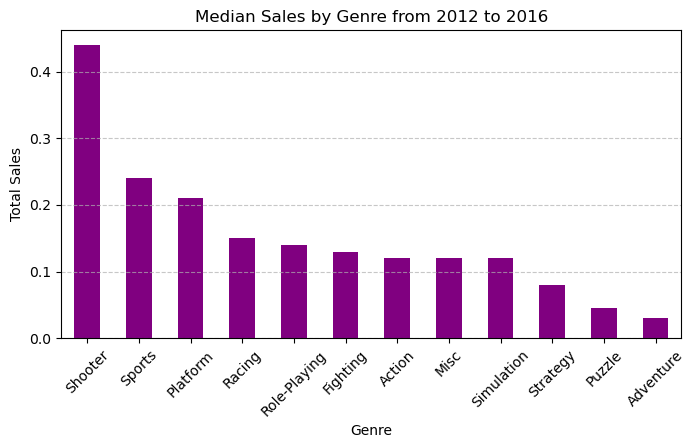

In [42]:
# Creating a bar chart  
plt.figure(figsize=(8, 4))  
median_sales_by_genre.plot(kind='bar', color='purple')  
plt.title('Median Sales by Genre from 2012 to 2016')  
plt.xlabel('Genre')  
plt.ylabel('Total Sales')  
plt.xticks(rotation=45)  # Rotate genre names on the X-axis for better readability  
plt.grid(axis='y', linestyle='--', alpha=0.7)  
plt.show()

**Conclusion:**

- **Most profitable genres:**  
  - **Shooter** (median sales — 0.44 million copies)  
  - **Sports** (median sales — 0.24 million copies)  
  - **Platform** (median sales — around 0.21 million copies)

- **Genres with moderate sales:**  
  - **Racing**, **Role-Playing**, **Fighting**, and **Action**  
  - Genres with the highest number of games:  
    - **Action** — 1031 games  
    - **Role-Playing** — 370 games

- **Genres with low sales:**  
  - **Misc**, **Simulation**, **Strategy**, **Puzzle**, and **Adventure**.

### Create a user profile for each region

We will determine the most popular platforms (Top 5) for users in each region (NA, EU, JP).

We'll use data for the relevant period (from 2012 onward).

#### Most popular platforms

[Additional information](https://en.wikipedia.org/wiki/List_of_best-selling_game_consoles)

In [43]:
def get_top_platforms_with_others(df, region_sales_col, top_n=5):
    # Group by platform and sum the sales
    platforms_grouped = df.groupby('platform')[region_sales_col].sum().sort_values(ascending=False)
    # Get the top_n most popular platforms
    top_platforms = platforms_grouped.head(top_n).reset_index()
    # Sum the sales of the remaining platforms
    others_sales = platforms_grouped.iloc[top_n:].sum()
    # Add the "Other" category
    others_row = pd.DataFrame([['Other', others_sales]], columns=['platform', region_sales_col])
    # Combine the top_n platforms and the "Other" category
    final = pd.concat([top_platforms, others_row], ignore_index=True)
    return final


# Get top platforms with 'others' grouped for each region
final_na = get_top_platforms_with_others(df_actual, 'na_sales')
final_eu = get_top_platforms_with_others(df_actual, 'eu_sales')
final_jp = get_top_platforms_with_others(df_actual, 'jp_sales')


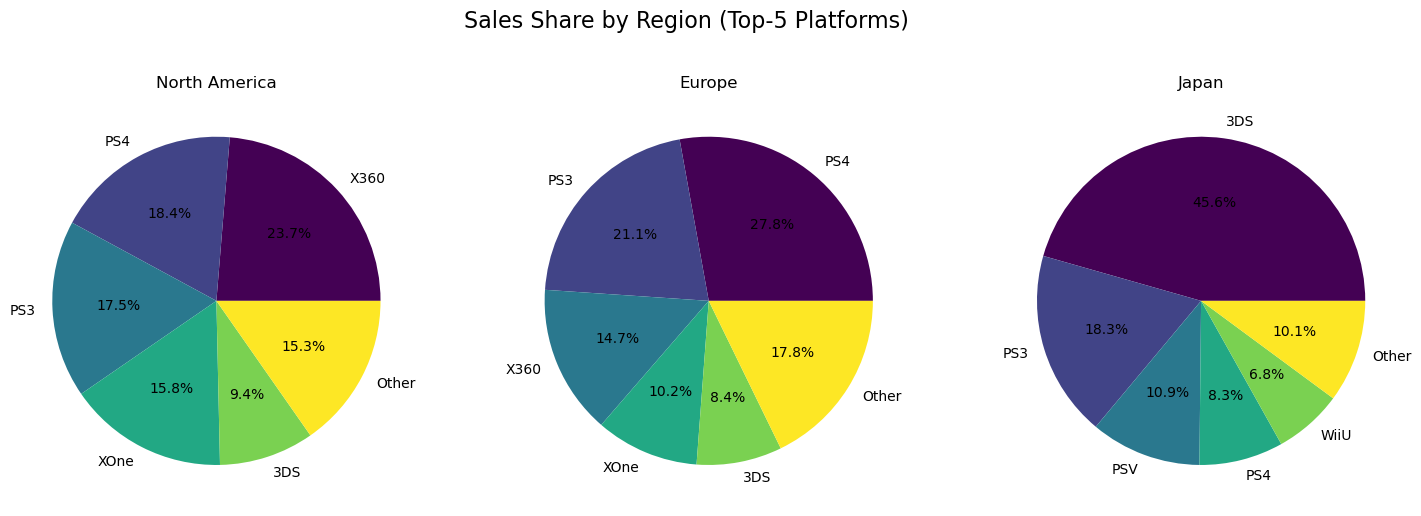

In [44]:
# Create a figure and axes for three pie charts
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot pie charts
final_na.plot(kind='pie', y='na_sales', labels=final_na['platform'], autopct='%1.1f%%', 
              ax=axes[0], legend=False, cmap='viridis')
axes[0].set_ylabel("")
axes[0].set_title('North America')

final_eu.plot(kind='pie', y='eu_sales', labels=final_eu['platform'], autopct='%1.1f%%', 
              ax=axes[1], legend=False, cmap='viridis')
axes[1].set_ylabel("")
axes[1].set_title('Europe')

final_jp.plot(kind='pie', y='jp_sales', labels=final_jp['platform'], autopct='%1.1f%%', 
              ax=axes[2], legend=False, cmap='viridis')
axes[2].set_ylabel("")
axes[2].set_title('Japan')

# Set the overall title for all charts
plt.suptitle('Sales Share by Region (Top-5 Platforms)', fontsize=16)
plt.show()


**North America (NA):** The most popular platform in this region is X360 (23.7%), followed by PS4 (18.4%). PS3 also holds a significant market share (17.5%). The top five are completed by XOne (15.8%) and 3DS (9.4%). Other platforms account for 15.3% of the market.

**Europe (EU):** PS4 leads with 27.8%, followed by PS3 at 21.1%, X360 (14.7%), XOne (10.2%), and 3DS (8.4%). Other platforms hold a 17.8% market share.

**Japan (JP):** 3DS dominates with 45.6% of sales, followed by PS3 (18.3%) and PSV (10.9%). PS4 (8.3%) and WiiU (6.8%) also hold notable shares. Other platforms account for 10.1% of the market.


#### Most Popular Genres (Top-5)


In [45]:
# View the most popular genres in North America
top_genres_na = df_actual.groupby('genre')['na_sales'].sum().sort_values(ascending=False).head(5)
top_genres_na.to_frame()


,na_sales
genre,
Action,177.84
Shooter,144.77
Sports,81.53
Role-Playing,64.00
Misc,38.19


In [46]:
# View the most popular genres in Europe
top_genres_eu = df_actual.groupby('genre')['eu_sales'].sum().sort_values(ascending=False).head(5)
top_genres_eu.to_frame()


,eu_sales
genre,
Action,159.34
Shooter,113.47
Sports,69.08
Role-Playing,48.53
Racing,27.23


In [47]:
# View the most popular genres in Japan
top_genres_jp = df_actual.groupby('genre')['jp_sales'].sum().sort_values(ascending=False).head(5)
top_genres_jp.to_frame()


,jp_sales
genre,
Role-Playing,65.44
Action,52.80
Misc,12.86
Simulation,10.41
Fighting,9.44


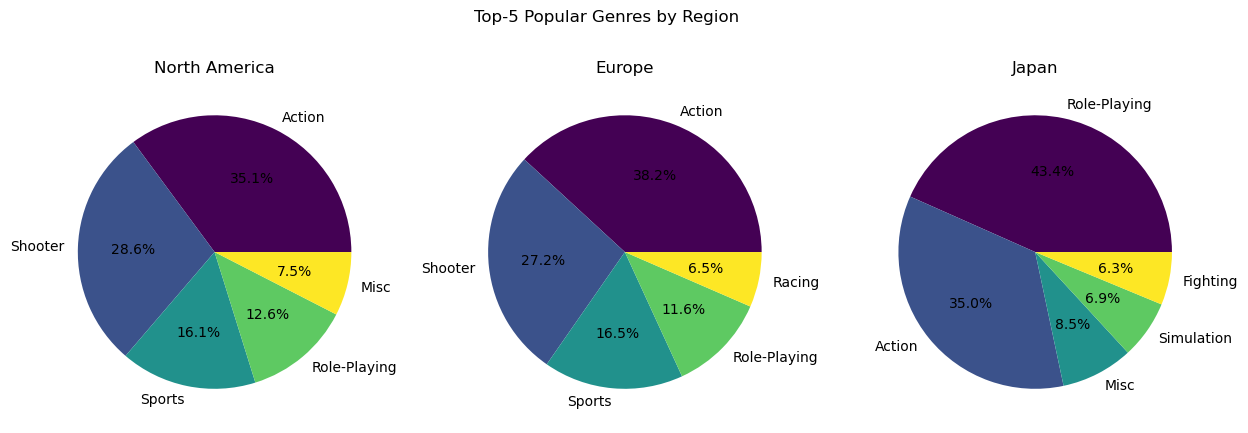

In [48]:
# Create a figure and axes for three pie charts
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot pie charts
top_genres_na.plot(kind='pie', ax=axes[0], autopct='%1.1f%%', colormap='viridis', legend=False)
axes[0].set_ylabel("")
axes[0].set_title('North America')

top_genres_eu.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colormap='viridis', legend=False)
axes[1].set_ylabel("")
axes[1].set_title('Europe')

top_genres_jp.plot(kind='pie', ax=axes[2], autopct='%1.1f%%', colormap='viridis', legend=False)
axes[2].set_ylabel("")
axes[2].set_title('Japan')

# Set the overall title for all charts
plt.suptitle('Top-5 Popular Genres by Region')
plt.show()


**North America (NA):**  
- **Action** dominates (35.1% market share), indicating a preference for dynamic and thrilling games.  
- **Shooter** ranks second (28.6%), confirming the popularity of shooting-focused games.  
- **Sports** comes third (16.1%).  
- Moderately popular genres include **Role-Playing (RPG)** (12.6%) and **Misc** (7.5%).

**Europe (EU):**  
- The popular genres are nearly identical to North America:  
  - **Action** — 38.1%  
  - **Shooter** — 27.2%  
  - **Sports** — 16.5%  
  - **Role-Playing** — 11.6%  
- A notable difference is the 5th place genre — **Racing** (6.5%), which is more popular in Europe.

**Japan (JP):**  
- Japanese players have unique preferences, reflecting cultural focus on story and depth.  
- **Role-Playing** games dominate (43.3% market share).  
- **Action** is also highly popular (35.0%).  
- There's also noticeable interest in **Misc** (8.5%), **Simulation** (6.9%), and **Fighting** (6.3%).
ighting** (6.3%).


**Conclusion:**

- The **Action** genre is popular across all considered regions.
- **Europe** and **North America** show nearly identical genre preferences.
- **Japan** differs, with a clear dominance of **Role-Playing** games.
**.


#### Influence of ESRB Rating on Sales in Specific Regions


In [49]:
# Pivot table: total sales per ESRB rating for each region
pivot_esrb = df_actual.pivot_table(values=['na_sales', 'eu_sales', 'jp_sales'], 
                                   index='rating', 
                                   aggfunc='sum')
pivot_esrb


,eu_sales,jp_sales,na_sales
rating,,,
E,113.02,28.33,114.37
E10+,55.37,8.19,75.70
M,193.96,21.20,231.57
T,52.90,26.02,66.02
undefined,91.50,108.84,103.31


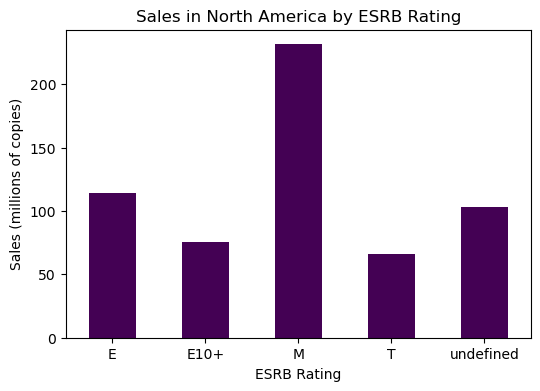

In [56]:
# Sales in North America
pivot_esrb['na_sales'].plot(kind='bar', cmap='viridis', 
                            title='Sales in North America by ESRB Rating', figsize=(6, 4))
plt.xlabel('ESRB Rating')
plt.ylabel('Sales (millions of copies)')
plt.xticks(rotation=0) 
plt.show()


**North America (NA):**

- **Rating M (Mature)** dominates with **231.57 million** copies sold — far exceeding other ratings. This indicates a strong preference for adult content.
- **Rating E (Everyone)** also performs well — **114.37 million** copies.
- **E10+ (Everyone 10 and older)** and **T (Teen)** ratings have the lowest sales.
го.


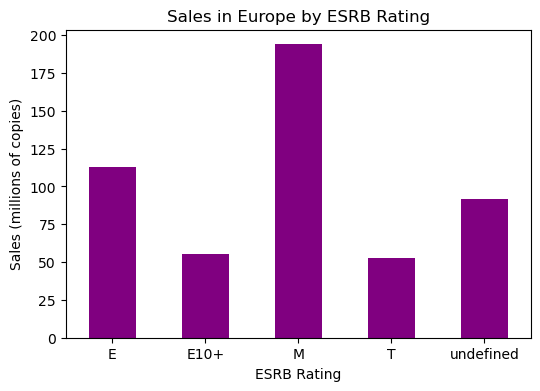

In [57]:
# Sales in Europe
pivot_esrb['eu_sales'].plot(kind='bar', color='purple', 
                            title='Sales in Europe by ESRB Rating', figsize=(6, 4))
plt.xlabel('ESRB Rating')
plt.ylabel('Sales (millions of copies)')
plt.xticks(rotation=0) 
plt.show()


**Europe (EU):**

- **Rating M (Mature)** leads with **193.96 million** copies sold.
- **Rating E (Everyone)** follows with **113.03 million**.
- **E10+** and **T** ratings show significantly lower sales.
же.


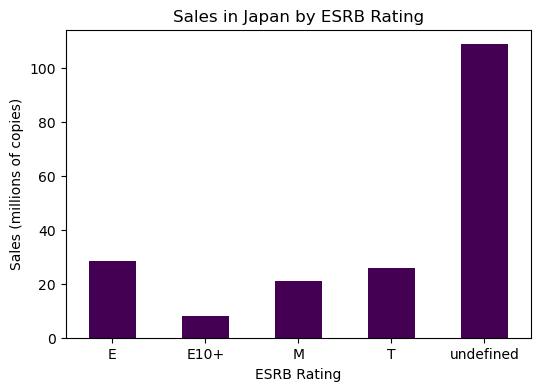

In [59]:
# Sales in Japan
pivot_esrb['jp_sales'].plot(kind='bar', cmap='viridis', 
                            title='Sales in Japan by ESRB Rating', figsize=(6, 4))
plt.xlabel('ESRB Rating')
plt.ylabel('Sales (millions of copies)')
plt.xticks(rotation=0) 
plt.show()


**Japan (JP):**

- **Rating E (Everyone)** shows the highest sales — **28.33 million** copies, reflecting a preference for family-friendly games.
- **Rating T (Teen)** also sells well — **26.02 million**.
- **Rating M (Mature)** is slightly lower — **21.2 million**.
- **Rating E10+** shows the lowest sales, indicating limited popularity for content aimed at older kids.
лет.


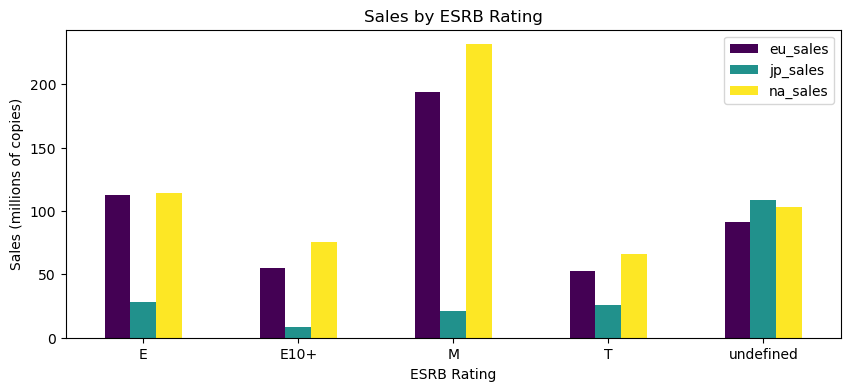

In [53]:
# Combined bar chart for all regions by ESRB Rating
pivot_esrb.plot(kind='bar', figsize=(10, 4), colormap='viridis', title='Sales by ESRB Rating')
plt.xlabel('ESRB Rating')
plt.ylabel('Sales (millions of copies)')
plt.xticks(rotation=0) 
plt.show()


- **Rating M (Mature)** dominates sales in both North America and Europe, indicating high demand for adult games.
- **Rating E (Everyone)** ranks second in both NA and EU and takes the lead in Japan, highlighting the importance of family-friendly games across all regions.
- In **Japan**, the top-selling ratings are **E** and **T (Teen)**, reflecting cultural preferences for youth-appropriate content.
- **E10+ (Everyone 10 and older)** consistently shows the lowest sales across all regions, suggesting a narrower target audience.
га.


**Summary:**

- **North American users** prefer dynamic and action-packed games, especially the **Action** and **Shooter** genres.  
  - **Sports** games are also quite popular.  
  - Games rated **M (Mature)** dominate in sales, showing strong demand for adult content.  
  - **E (Everyone)** rated games also have a large market share.  
  - Top platforms: **X360** (23.7%), **PS4** (18.4%), **PS3** (17.5%), **XOne** (15.8%), **3DS** (9.4%). Others: 15.3%.

- **European users** resemble American ones:  
  - Most popular genres: **Action**, **Shooter**, followed by **Sports** and **RPG**.  
  - Notably high interest in **Racing** games.  
  - **M (Mature)** and **E (Everyone)** ratings dominate.  
  - Top consoles: **PS4** (27.8%), **PS3** (21.1%), **X360** (14.7%), **XOne** (10.2%), **3DS** (8.4%). Others: 17.8%.

- **Japanese users** show unique cultural preferences:  
  - **Role-Playing (RPG)** is the leading genre, showing love for story-driven games.  
  - **Action** is also strong.  
  - Genres like **Misc**, **Simulation**, and **Fighting** are notable.  
  - Games rated **E** (28.33M) and **T** (26.02M) lead, while **M** is lower (21.2M); **E10+** has the lowest sales.  
  - Leading platforms: **3DS** (45.6%), **PS3** (18.3%), **PSV** (10.9%), **PS**
– 10.1% доли рынка.


### Hypothesis Testing


#### Hypothesis: The average user ratings for Xbox One and PC platforms are the same.


Null hypothesis — the average user ratings for Xbox One and PC platforms are equal.  
Alternative hypothesis — the average user ratings for Xbox One and PC platforms are different.

We'll use an independent two-sample t-test because:  
* We're comparing the means of two independent groups.  
* Ratings of one platform don’t influence ratings of the other.

Significance level: 5% (a common standard in statistical tests).


In [54]:
alpha = 0.05  # significance level

# Filter data for Xbox One and remove missing user scores
xone = df_actual[(df_actual['platform'] == 'XOne') & (df_actual['user_score'].notna())]['user_score']
pc = df_actual[(df_actual['platform'] == 'PC') & (df_actual['user_score'].notna())]['user_score']

# Run t-test
results = st.ttest_ind(xone, pc)

print('p-value:', results.pvalue)

if results.pvalue < alpha:
    print('Reject the null hypothesis')
else:
    print('Failed to reject the null hypothesis')


p-value: 0.5112133814834332
Failed to reject the null hypothesis


**Conclusion:**  
There is no statistical evidence to suggest that the average user ratings differ between Xbox One and PC platforms.


#### Hypothesis: The average user ratings for the Action and Sports genres are different.


- **Null hypothesis** — the average user ratings for Action and Sports genres are equal.  
- **Alternative hypothesis** — the average user ratings for Action and Sports genres are different.

We'll also use an independent two-sample t-test.

Significance level: 5%.


In [55]:
alpha = 0.05  # significance level

# Filter data for Action and Sports genres and remove missing user scores
xone = df_actual[(df_actual['genre'] == 'Action') & (df_actual['user_score'].notna())]['user_score']
pc = df_actual[(df_actual['genre'] == 'Sports') & (df_actual['user_score'].notna())]['user_score']

# Run t-test
results = st.ttest_ind(xone, pc)

print('p-value:', results.pvalue)

if results.pvalue < alpha:
    print('Reject the null hypothesis')
else:
    print('Failed to reject the null hypothesis')


p-value: 4.804523380462917e-26
Reject the null hypothesis


**Conclusion:**  
There is evidence to suggest that the average user ratings for Action and Sports genres are different.


### General Conclusion


#### Data Preprocessing Summary

- **Column names** were converted to lowercase.  
- **Data types** were adjusted: *year_of_release* → int, *user_score* → float.  
- **Missing values** were dropped from *name*, *year_of_release*, and *genre* due to their small number.  
  - Missing values in *rating*, *critic_score*, and *user_score* were left as-is to avoid skewing results.  
- **Duplicates:** Obvious duplicates were not found; 5 non obvious duplicates were removed.  
- **New column added:** Total sales across all regions were calculated and added.


#### Exploratory Data Analysis Findings

**Games released by year:**  
- Starting from the mid-90s, the number of games increased, peaking between 2005–2010.  
- After 2010, the number of releases began to decline.

**Lifecycle of high-selling platforms:**  
- Growth phase: 3–5 years; peak sales; decline after 5–7 years.  
- Understanding this cycle helps in planning marketing and development strategies.

> For 2017 forecasting, data was filtered up to 2012 (the peak). The decline may be due to shifting interest from consoles to smartphones and mobile gaming.

**Top-selling platforms:**  
- **PS4**, **PS3**, **X360**, **3DS**, **XOne**.  
- These platforms had hit games driving sales.  
- **PS4**, **XOne**, and **3DS** are potentially profitable, while others are near end-of-life.

**Impact of reviews on sales:**  
- **User_Score** has no strong impact on sales.  
- **Critic_Score** shows a weak positive correlation — some games sell well even with average reviews.

**Genre distribution:**  
- **Most profitable genres:**  
  - **Shooter** (median sales ~0.44M),  
  - **Sports** (~0.24M),  
  - **Platform** (~0.21M).  
- **Moderately selling genres:** Racing, RPG, Fighting, Action.  
- **Lowest sales:** Misc, Simulation, Strategy, Puzzle, Adventure.  
- **Action** had the most releases (1031 games, 441.12M total sales);  
  **RPG** had 370 games, 192.80M total sales.


### Hypothesis Testing Conclusions

- **Are the average user ratings for Xbox One and PC platforms the same?**  
There is no sufficient evidence to suggest they are different.

- **Are the average user ratings for Action and Sports genres different?**  
There is sufficient evidence to suggest they are different.

---

#### Recommendations for the Stakeholder:

**Focus on Popular Platforms**  
- **Key platforms for North America and Europe:**  
  - **PS4** and **XOne** are recommended, as they are not at the end of their lifecycle and generate strong sales.  
  - **3DS** remains promising in Japan, where it holds a large market share, even if its global sales are lower.

**Target Top-Selling Genres**  
- **North America and Europe:**  
  - Prioritize **Shooter** and **Sports** genres, which show the highest median sales.  
  - **Action** is also popular and widely played, but market saturation suggests cautious investment.  
  - Marketing campaigns should emphasize dynamics and excitement.

- **Japan:**  
  - Emphasize **Role-Playing** games, which dominate the Japanese market.  
  - Marketing should highlight storytelling and game depth.

**Account for Regional Preferences and ESRB Ratings**  
- **North America and Europe:**  
  - Continue to expand offerings rated **M (Mature)** due to their high demand.  
  - Games rated **E (Everyone)** are also important for mass-market success.

- **Japan:**  
  - Focus on games rated **E** and **T (Teen)**, which lead in sales.  
  - Less emphasis on **Mature** or **E10+** titles.
